In [ ]:
# Algorithùe Branch and Bound pour resoudre un PLNE


In [1]:
import numpy as np
import pandas as pd
from docplex.mp.model import Model

def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2"])

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

# Exécution de l'algorithme
solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

# Affichage des résultats
print("\n--- Résultats de l'algorithme Branch and Bound ---")
print(f"La solution optimale de l'algorithme Branch and Bound est : {solution}")
print(f"La valeur optimale associée est : {optimal_value}")
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)

# Message final
if solution:
    print("\n*** La solution finale de l'algorithme Branch and Bound est ***")
    print(f"Solution optimale : {solution}")
    print(f"Valeur optimale : {optimal_value}")
else:
    print("\n*** Aucune solution admissible trouvée par l'algorithme Branch and Bound ***")
    
    
# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()    


--- Résultats de l'algorithme Branch and Bound ---
La solution optimale de l'algorithme Branch and Bound est : {'x1': 2.0, 'x2': 1.0}
La valeur optimale associée est : 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0            

NameError: name 'plt' is not defined

In [ ]:

#La résolution des Relaxation continue linéaire avec simplexe pour l'évaluation de chaque noeud de l'arbre B&B


Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 1 rows and 0 columns.
Reduced LP has 2 rows, 2 columns, and 4 nonzeros.
Presolve time = 0.02 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual infeasibility =             0.142856
Point optimal: x1 = 2.86, x2 = 3.00
Valeur optimale de Z: 8.43


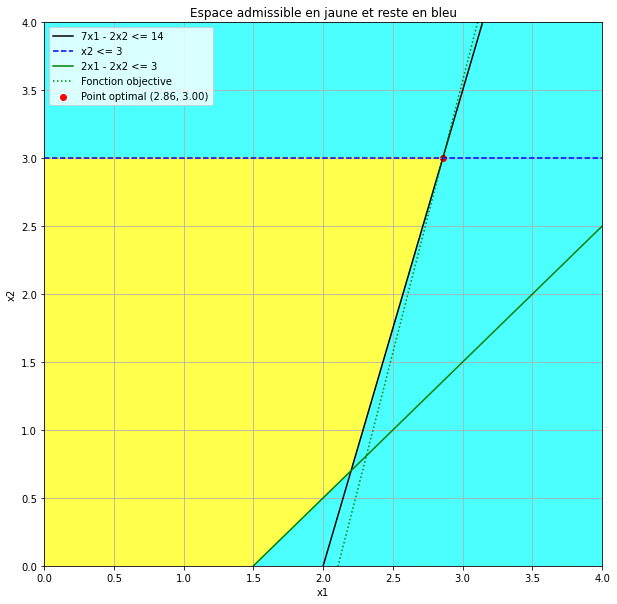

In [2]:
                                    # Noeud Racine ( Noued 0)

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
#mdl.add_constraint(x1 <= 2, "Constraint4")
#mdl.add_constraint(x2 >= 1, "Constraint5")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
#c4 = (X <= 2)
#c5 = (Y >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
#plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
#plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 3 rows and 0 columns.
Reduced LP has 1 rows, 2 columns, and 2 nonzeros.
Presolve time = 0.02 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual objective     =             7.500000
Point optimal: x1 = 2.00, x2 = 0.50
Valeur optimale de Z: 7.50


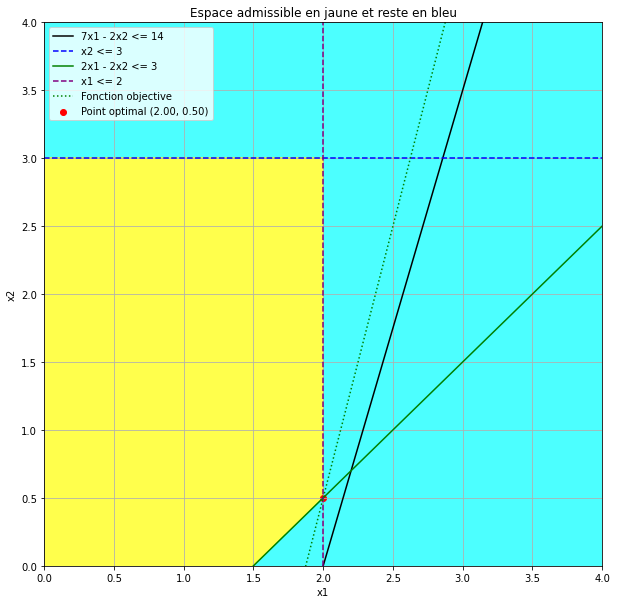

In [3]:
                                     # NOEUD 1

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
#mdl.add_constraint(x2 >= 1, "Constraint5")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
#c5 = (Y >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
#plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 5 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.02 sec. (0.00 ticks)
Point optimal: x1 = 1.50, x2 = 0.00
Valeur optimale de Z: 6.00


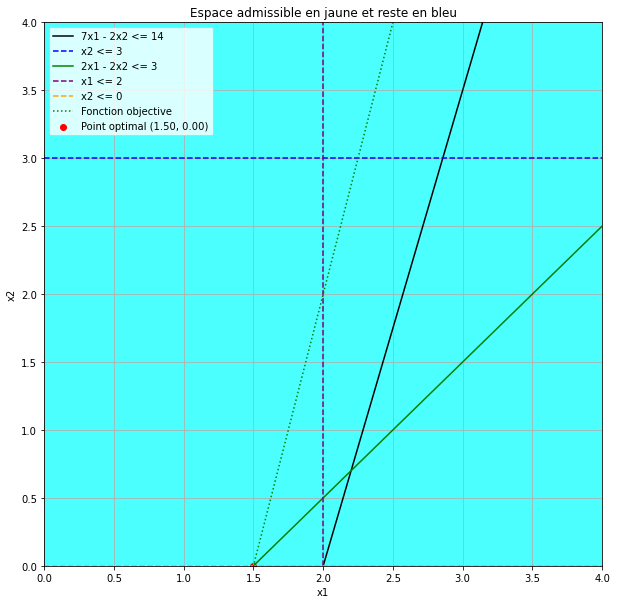

In [4]:
                                       # N

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 <= 0, "Constraint5")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 6 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.02 sec. (0.00 ticks)
Point optimal: x1 = 1.00, x2 = 0.00
Valeur optimale de Z: 4.00


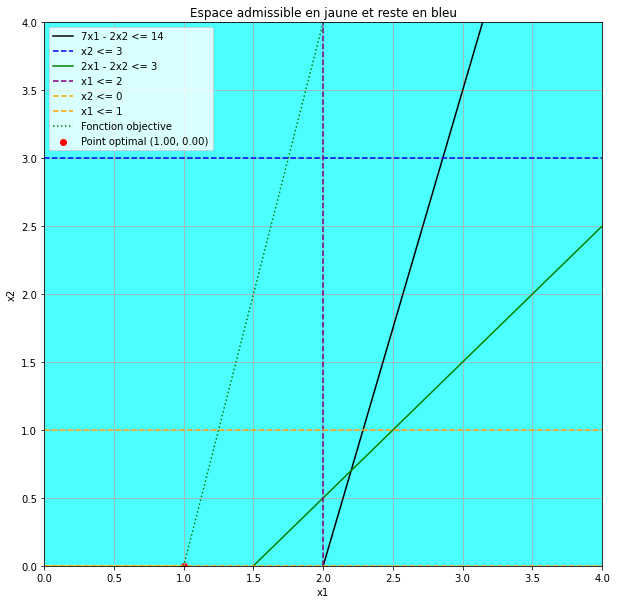

In [5]:
                                   # NOEUD 3

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 <= 0, "Constraint5")
mdl.add_constraint(x1 <= 1, "Constraint6")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)
c6 = (X <= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5 & c6

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")
plt.axhline(1, color="orange", linestyle="--", label="x1 <= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Infeasibility row 'Constraint3':  0 <= -1.
Presolve time = 0.01 sec. (0.00 ticks)
Aucune solution trouvée.


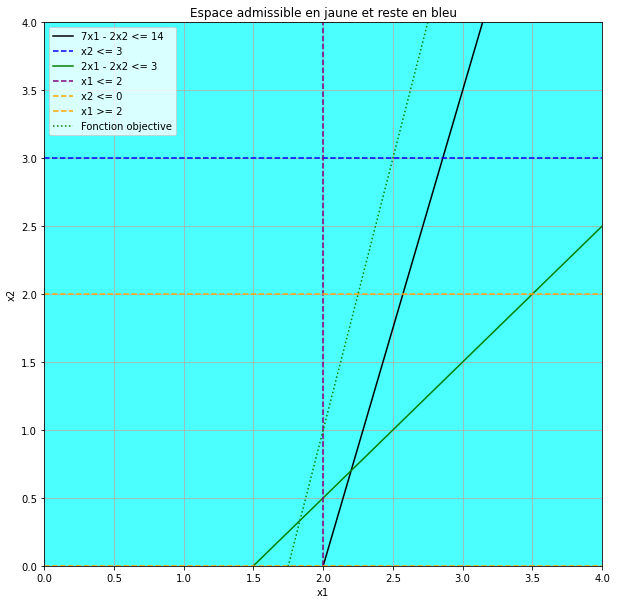

In [189]:
                                 # NOEUD 4

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 <= 0, "Constraint5")
mdl.add_constraint(x1 >= 2, "Constraint6")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)
c6 = (X >= 2)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5 & c6

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")
plt.axhline(2, color="orange", linestyle="--", label="x1 >= 2")

# Tracer le point optimal
#plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 5 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.00 sec. (0.00 ticks)
Point optimal: x1 = 2.00, x2 = 1.00
Valeur optimale de Z: 7.00


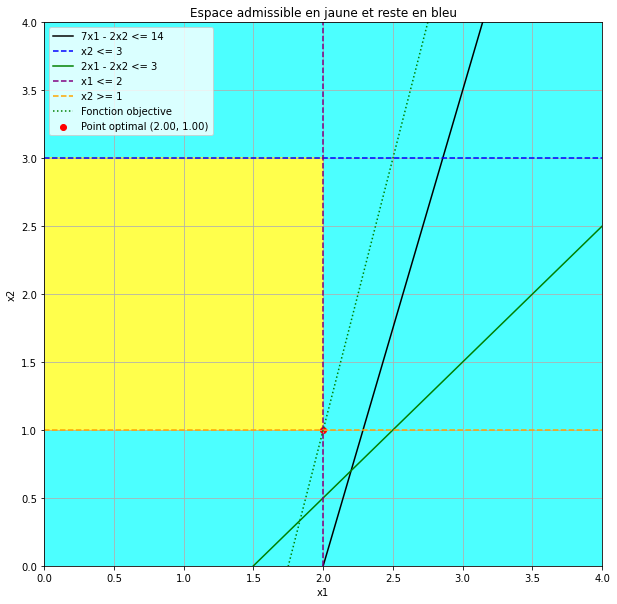

In [171]:
                              # noeud 5
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 >= 1, "Constraint5")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Row 'Constraint1' infeasible, all entries at implied bounds.
Presolve time = 0.00 sec. (0.00 ticks)
Aucune solution trouvée.


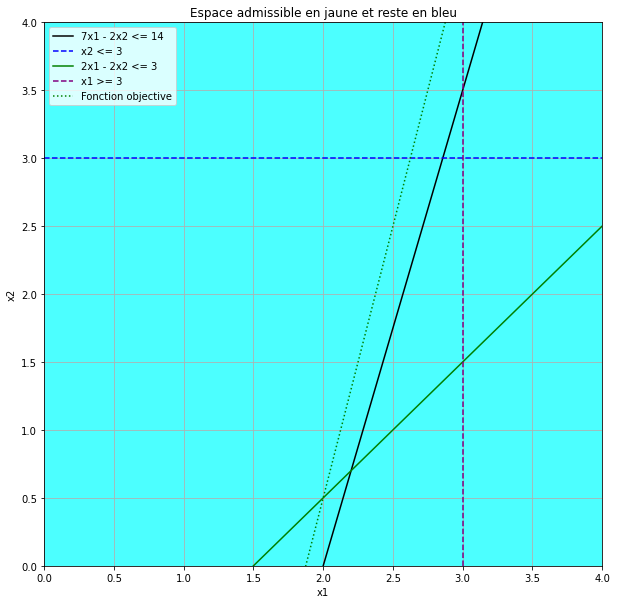

In [194]:
                                    # NOEUD E 6

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 >= 3, "Constraint4")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X >= 3)


# Région faisable
feasible_region = c1 & c2 & c3 & c4 

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(3, color="purple", linestyle="--", label="x1 >= 3")


# Tracer le point optimal
#plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

In [ ]:
 
                           # La finnnnnnnnnnnnnn de l'arbre     
        

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 5 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.01 sec. (0.00 ticks)
Point optimal: x1 = 1.50, x2 = 0.00
Valeur optimale de Z: 6.00


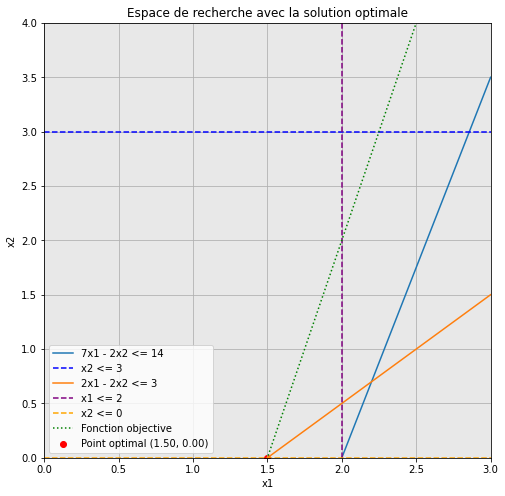

In [6]:
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 <= 0, "Constraint4")
#mdl.add_constraint(x1 <= 1, "Constraint5")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 3, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5

# Tracer la région faisable
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['lightgrey'], alpha=0.5)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")

# Configuration du graphique
plt.xlim(0, 3)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche avec la solution optimale")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 6 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.03 sec. (0.00 ticks)
Point optimal: x1 = 1.00, x2 = 0.00
Valeur optimale de Z: 4.00


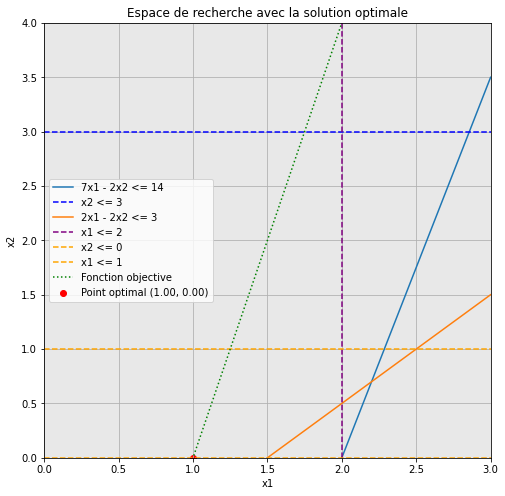

In [169]:
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 <= 0, "Constraint5")
mdl.add_constraint(x1 <= 1, "Constraint6")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 3, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)
c6 = (X <= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5 & c6

# Tracer la région faisable
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['lightgrey'], alpha=0.5)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")
plt.axhline(1, color="orange", linestyle="--", label="x1 <= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")

# Configuration du graphique
plt.xlim(0, 3)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche avec la solution optimale")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Infeasibility row 'Constraint3':  0 <= -1.
Presolve time = 0.03 sec. (0.00 ticks)
Aucune solution trouvée.


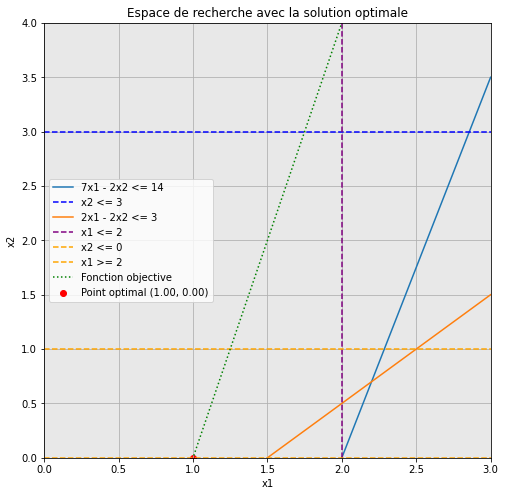

In [170]:
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 <= 0, "Constraint5")
mdl.add_constraint(x1 >= 2, "Constraint6")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 3, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)
c6 = (X >= 2)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5 & c6

# Tracer la région faisable
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['lightgrey'], alpha=0.5)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")
plt.axhline(1, color="orange", linestyle="--", label="x1 >= 2")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")

# Configuration du graphique
plt.xlim(0, 3)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche avec la solution optimale")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 3 rows and 0 columns.
Reduced LP has 1 rows, 2 columns, and 2 nonzeros.
Presolve time = 0.00 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual objective     =             7.500000
Point optimal: x1 = 2.00, x2 = 0.50
Valeur optimale de Z: 7.50


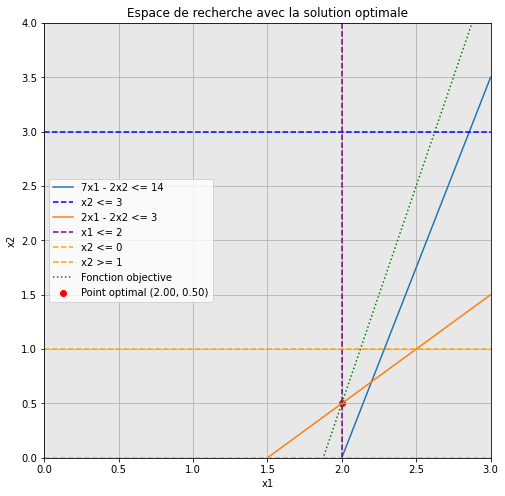

In [192]:
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")


# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 3, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y <= 0)
c6 = (X >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5 & c6

# Tracer la région faisable
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['lightgrey'], alpha=0.5)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(0, color="orange", linestyle="--", label="x2 <= 0")
plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")

# Configuration du graphique
plt.xlim(0, 3)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche avec la solution optimale")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 5 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.00 sec. (0.00 ticks)
Point optimal: x1 = 2.00, x2 = 1.00
Valeur optimale de Z: 7.00


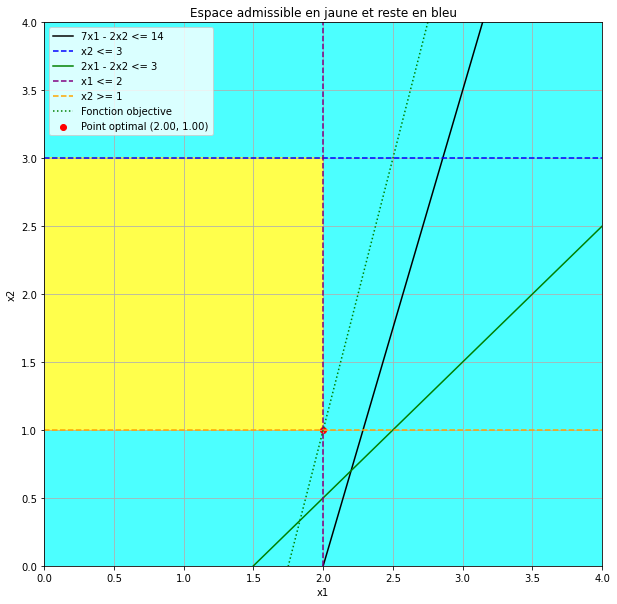

In [146]:
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 >= 1, "Constraint5")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Row 'Constraint1' infeasible, all entries at implied bounds.
Presolve time = 0.00 sec. (0.00 ticks)
Aucune solution trouvée.


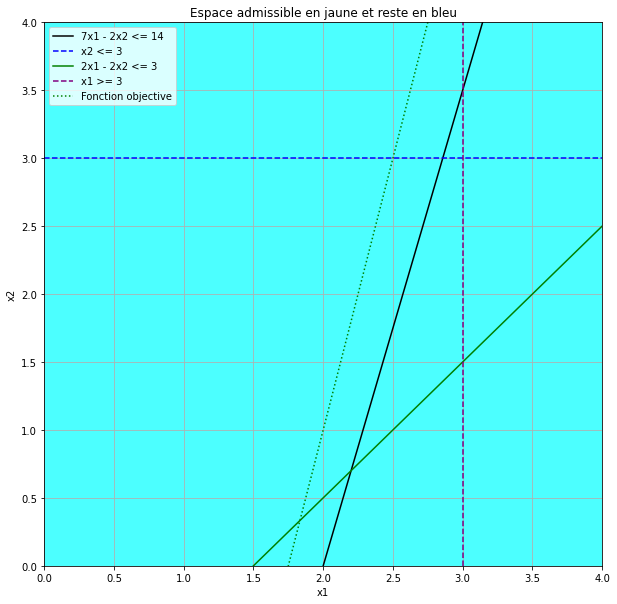

In [191]:
                                 # NOEUD final

from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="Simplexe_MaxZ")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 >= 3, "Constraint4")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal: x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z: {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X >= 3)


# Région faisable
feasible_region = c1 & c2 & c3 & c4 

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(3, color="purple", linestyle="--", label="x1 >= 3")


# Tracer le point optimal
#plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

In [ ]:




                           # La finnnnnnnnnnnnnn de l'arbre






Point optimal : x1 = 1.00, x2 = 2.00
Valeur optimale de z : 2.00


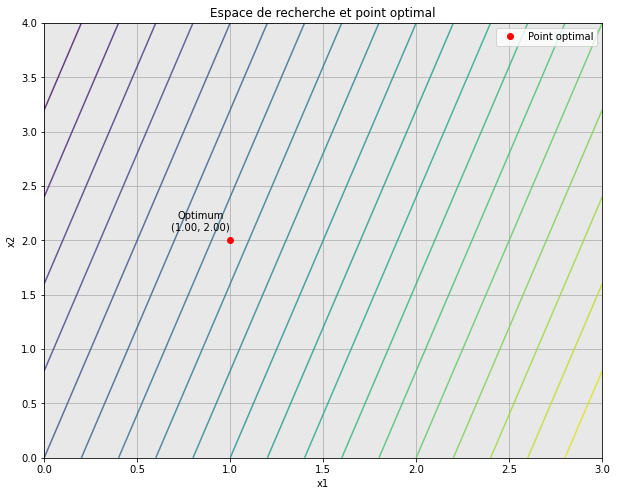

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name='Simplexe')

# Variables de décision
x1 = mdl.continuous_var(name='x1', lb=0)
x2 = mdl.continuous_var(name='x2', lb=0)  # x2 >= 0

# Fonction objective (maximisation)
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, 'c1')
mdl.add_constraint(x2 <= 3, 'c2')
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, 'c3')
mdl.add_constraint(x1 <= 1, 'c4')
mdl.add_constraint(x2 >= 2, 'c5')  # x2 >= 0

# Résolution
solution = mdl.solve()

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de z : {z_opt:.2f}")
else:
    print("Pas de solution optimale trouvée.")

# Visualisation de l'espace de recherche
x1_vals = np.linspace(0, 3, 400)
x2_vals = np.linspace(0, 4, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Fonction pour tester les contraintes
def is_feasible(x1, x2):
    return (
        7 * x1 - 2 * x2 <= 14 and
        x2 <= 3 and
        2 * x1 - 2 * x2 <= 3 and
        x1 <= 1 and
        x2 >= 2
    )

# Calcul de la faisabilité
feasible = np.vectorize(is_feasible)(X1, X2)

# Tracé de l'espace de recherche
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, feasible, levels=[0, 1], colors=['lightgrey', 'white'], alpha=0.5)

# Tracé de la fonction objective
z = 4 * X1 - X2
plt.contour(X1, X2, z, levels=20, cmap='viridis', alpha=0.8)

# Point optimal
if solution:
    plt.plot(x1_opt, x2_opt, 'ro', label='Point optimal')
    plt.annotate(f"Optimum\n({x1_opt:.2f}, {x2_opt:.2f})", (x1_opt, x2_opt), textcoords="offset points", xytext=(-30,10), ha='center')

# Configurations du graphique
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche et point optimal")
plt.legend()
plt.grid()
plt.show()


Point optimal : x1 = 1.00, x2 = 2.00
Valeur optimale de z : 2.00


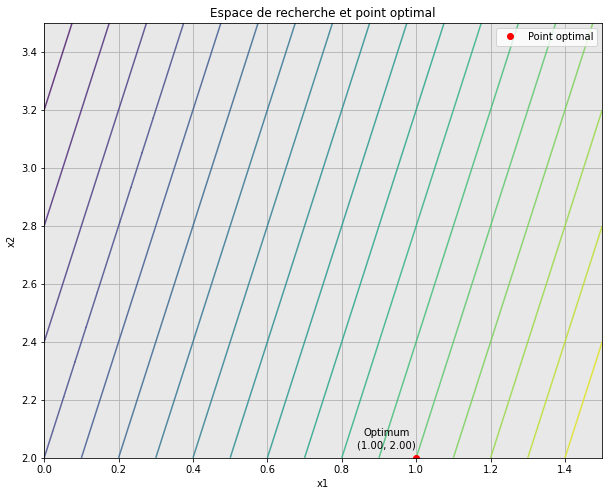

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name='Simplexe')

# Variables de décision
x1 = mdl.continuous_var(name='x1', lb=0)
x2 = mdl.continuous_var(name='x2', lb=2)  # x2 >= 2

# Fonction objective (maximisation)
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, 'c1')
mdl.add_constraint(x2 <= 3, 'c2')
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, 'c3')
mdl.add_constraint(x1 <= 1, 'c4')
mdl.add_constraint(x2 >= 2, 'c5')  # Explicite, bien que redondante avec lb=2

# Résolution
solution = mdl.solve()

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de z : {z_opt:.2f}")
else:
    print("Pas de solution optimale trouvée.")

# Visualisation de l'espace de recherche
x1_vals = np.linspace(0, 1.5, 400)
x2_vals = np.linspace(2, 3.5, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Fonction pour tester les contraintes
def is_feasible(x1, x2):
    return (
        7 * x1 - 2 * x2 <= 14 and
        x2 <= 3 and
        2 * x1 - 2 * x2 <= 3 and
        x1 <= 1 and
        x2 >= 2
    )

# Calcul de la faisabilité
feasible = np.vectorize(is_feasible)(X1, X2)

# Tracé de l'espace de recherche
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, feasible, levels=[0, 1], colors=['lightgrey', 'white'], alpha=0.5)

# Tracé de la fonction objective
z = 4 * X1 - X2
plt.contour(X1, X2, z, levels=20, cmap='viridis', alpha=0.8)

# Point optimal
if solution:
    plt.plot(x1_opt, x2_opt, 'ro', label='Point optimal')
    plt.annotate(f"Optimum\n({x1_opt:.2f}, {x2_opt:.2f})", (x1_opt, x2_opt), textcoords="offset points", xytext=(-30,10), ha='center')

# Configurations du graphique
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche et point optimal")
plt.legend()
plt.grid()
plt.show()


Point optimal : x1 = 2.00, x2 = 0.50
Valeur optimale de z : 7.50


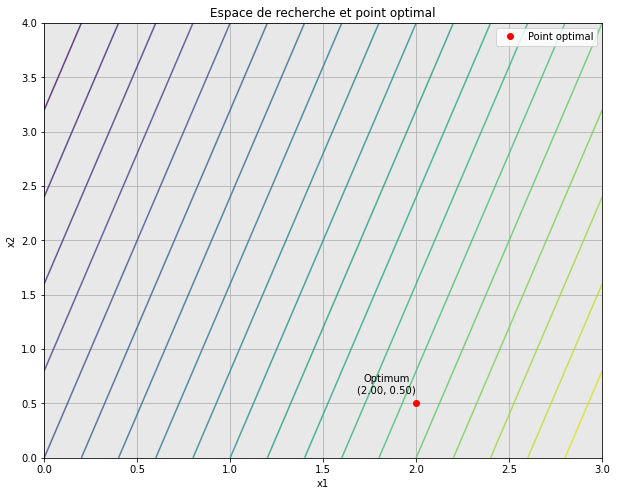

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name='Simplexe')

# Variables de décision
x1 = mdl.continuous_var(name='x1', lb=0)
x2 = mdl.continuous_var(name='x2', lb=0)

# Fonction objective (maximisation)
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, 'c1')
mdl.add_constraint(x2 <= 3, 'c2')
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, 'c3')
mdl.add_constraint(x1 <= 2, 'c4')
mdl.add_constraint(x2 <= 1, 'c5')

# Résolution
solution = mdl.solve()

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de z : {z_opt:.2f}")
else:
    print("Pas de solution optimale trouvée.")

# Visualisation de l'espace de recherche
x1_vals = np.linspace(0, 3, 400)
x2_vals = np.linspace(0, 4, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Fonction pour tester les contraintes
def is_feasible(x1, x2):
    return (
        7 * x1 - 2 * x2 <= 14 and
        x2 <= 3 and
        2 * x1 - 2 * x2 <= 3 and
        x1 >= 3
        #x1 <= 2 and
        #x2 <= 1 and
        #x2 >= 0
    )

# Calcul de la faisabilité
feasible = np.vectorize(is_feasible)(X1, X2)

# Tracé de l'espace de recherche
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, feasible, levels=[0, 1], colors=['lightgrey', 'white'], alpha=0.5)

# Tracé de la fonction objective
z = 4 * X1 - X2
plt.contour(X1, X2, z, levels=20, cmap='viridis', alpha=0.8)

# Point optimal
if solution:
    plt.plot(x1_opt, x2_opt, 'ro', label='Point optimal')
    plt.annotate(f"Optimum\n({x1_opt:.2f}, {x2_opt:.2f})", (x1_opt, x2_opt), textcoords="offset points", xytext=(-30,10), ha='center')

# Configurations du graphique
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche et point optimal")
plt.legend()
plt.grid()
plt.show()

Point optimal : x1 = 2.00, x2 = 0.50
Valeur optimale de z : 7.50


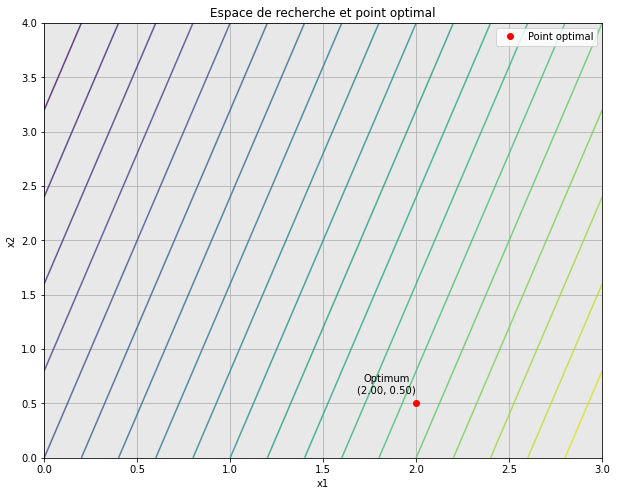

In [100]:











import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name='Simplexe')

# Variables de décision
x1 = mdl.continuous_var(name='x1', lb=0)
x2 = mdl.continuous_var(name='x2', lb=0)  # x2 >= 0

# Fonction objective (maximisation)
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, 'c1')
mdl.add_constraint(x2 <= 3, 'c2')
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, 'c3')
mdl.add_constraint(x1 <= 2, 'c4')
mdl.add_constraint(x2 >= 0, 'c5')  # x2 >= 0

# Résolution
solution = mdl.solve()

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de z : {z_opt:.2f}")
else:
    print("Pas de solution optimale trouvée.")

# Visualisation de l'espace de recherche
x1_vals = np.linspace(0, 3, 400)
x2_vals = np.linspace(0, 4, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Fonction pour tester les contraintes
def is_feasible(x1, x2):
    return (
        7 * x1 - 2 * x2 <= 14 and
        x2 <= 3 and
        2 * x1 - 2 * x2 <= 3 and
        x1 <= 2 and
        x2 >= 0
    )

# Calcul de la faisabilité
feasible = np.vectorize(is_feasible)(X1, X2)

# Tracé de l'espace de recherche
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, feasible, levels=[0, 1], colors=['lightgrey', 'white'], alpha=0.5)

# Tracé de la fonction objective
z = 4 * X1 - X2
plt.contour(X1, X2, z, levels=20, cmap='viridis', alpha=0.8)

# Point optimal
if solution:
    plt.plot(x1_opt, x2_opt, 'ro', label='Point optimal')
    plt.annotate(f"Optimum\n({x1_opt:.2f}, {x2_opt:.2f})", (x1_opt, x2_opt), textcoords="offset points", xytext=(-30,10), ha='center')

# Configurations du graphique
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace de recherche et point optimal")
plt.legend()
plt.grid()
plt.show()








TypeError: 'NoneType' object is not subscriptable

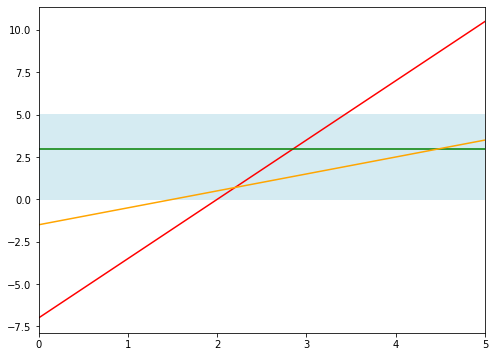

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from docplex.mp.model import Model

def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        visualize_node(sub_mdl, node_bounds, len(tree_nodes), is_final=False)

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    def visualize_node(model, bounds, node_id, is_final=False):
        x1 = np.linspace(0, 5, 400)
        x2 = np.linspace(0, 5, 400)
        X1, X2 = np.meshgrid(x1, x2)

        constraint1 = 7 * X1 - 2 * X2 <= 14
        constraint2 = X2 <= 3
        constraint3 = 2 * X1 - 2 * X2 <= 3
        constraint4 = (X1 >= bounds.get("x1", (0, 4))[0]) & (X1 <= bounds.get("x1", (0, 4))[1])
        constraint5 = (X2 >= bounds.get("x2", (0, 4))[0]) & (X2 <= bounds.get("x2", (0, 4))[1])

        admissible = constraint1 & constraint2 & constraint3 & constraint4 & constraint5

        if is_final and best_solution:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')
            plt.scatter(best_solution["x1"], best_solution["x2"], color='purple', s=100, label="Solution optimale")

            # Visualisation de la droite de la fonction objective
            x2_values = 4 * x1 - best_solution["x1"]  # Calcul des valeurs de x2 pour la droite de la fonction objectif
            plt.plot(x1, x2_values, label="Droite de la fonction objective", color='blue', linestyle='dashed')

            plt.title(f"Espace admissible - Nœud {node_id}" + (" (Final)" if is_final else ""))
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            plt.grid()
            plt.show()
        else:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')
            # Visualisation de la droite de la fonction objective
            x2_values = 4 * x1 - best_solution["x1"]  # Calcul des valeurs de x2 pour la droite de la fonction objectif
            plt.plot(x1, x2_values, label="Droite de la fonction objective", color='blue', linestyle='dashed')
            plt.title(f"Espace admissible - Nœud {node_id}")
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            plt.grid()
            plt.show()

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    if best_solution:
        visualize_node(mdl, {"x1": (0, 4), "x2": (0, 4)}, node_id="Final", is_final=True)

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)

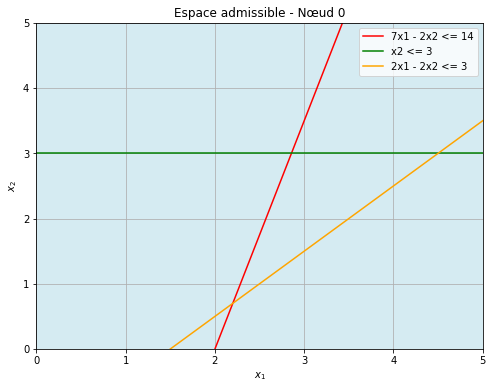

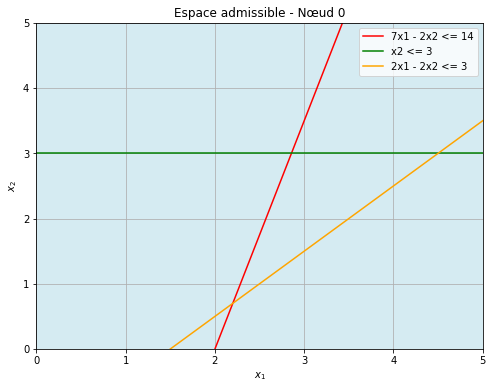

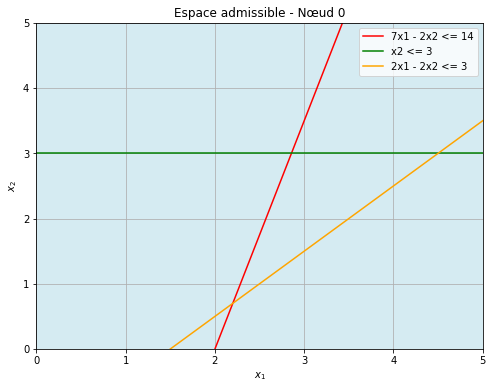

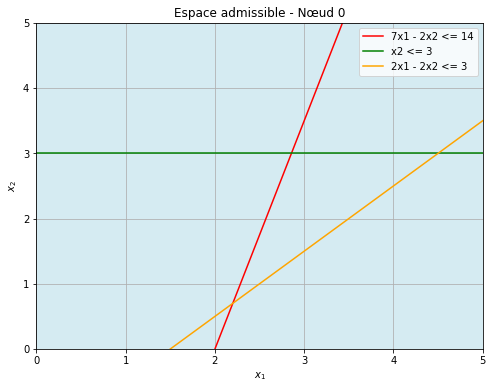

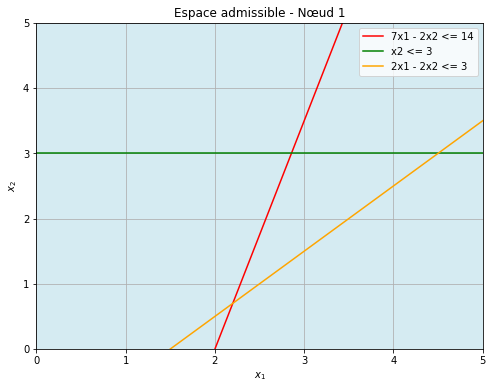

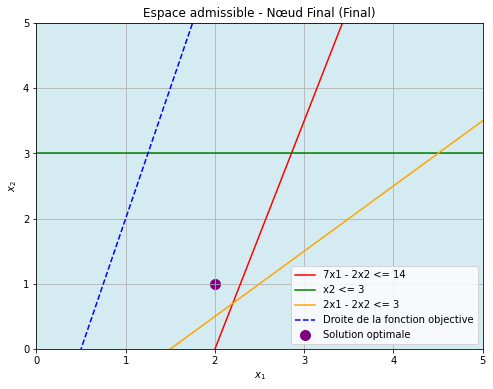

Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, '

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from docplex.mp.model import Model

def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        visualize_node(sub_mdl, node_bounds, len(tree_nodes), is_final=False)

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    def visualize_node(model, bounds, node_id, is_final=False):
        x1 = np.linspace(0, 5, 400)
        x2 = np.linspace(0, 5, 400)
        X1, X2 = np.meshgrid(x1, x2)

        constraint1 = 7 * X1 - 2 * X2 <= 14
        constraint2 = X2 <= 3
        constraint3 = 2 * X1 - 2 * X2 <= 3
        constraint4 = (X1 >= bounds.get("x1", (0, 4))[0]) & (X1 <= bounds.get("x1", (0, 4))[1])
        constraint5 = (X2 >= bounds.get("x2", (0, 4))[0]) & (X2 <= bounds.get("x2", (0, 4))[1])

        admissible = constraint1 & constraint2 & constraint3 & constraint4 & constraint5

        if is_final and best_solution:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')
            plt.scatter(best_solution["x1"], best_solution["x2"], color='purple', s=100, label="Solution optimale")

            # Visualisation de la droite de la fonction objective
            x2_values = 4 * x1 - best_solution["x1"]  # Calcul des valeurs de x2 pour la droite de la fonction objectif
            plt.plot(x1, x2_values, label="Droite de la fonction objective", color='blue', linestyle='dashed')

            plt.title(f"Espace admissible - Nœud {node_id}" + (" (Final)" if is_final else ""))
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            plt.grid()
            plt.show()
        else:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')

            plt.title(f"Espace admissible - Nœud {node_id}")
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            plt.grid()
            plt.show()

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    if best_solution:
        visualize_node(mdl, {"x1": (0, 4), "x2": (0, 4)}, node_id="Final", is_final=True)

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)

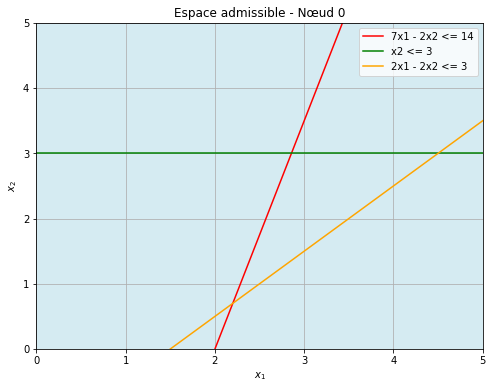

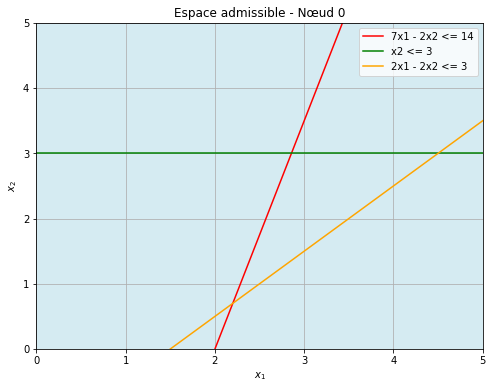

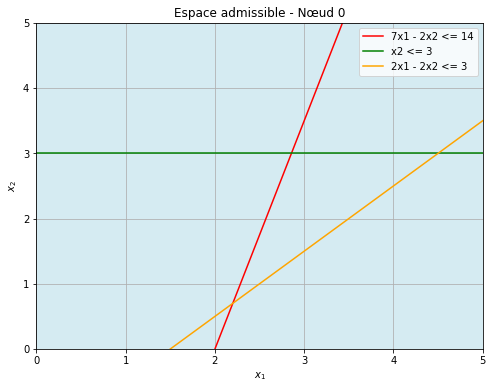

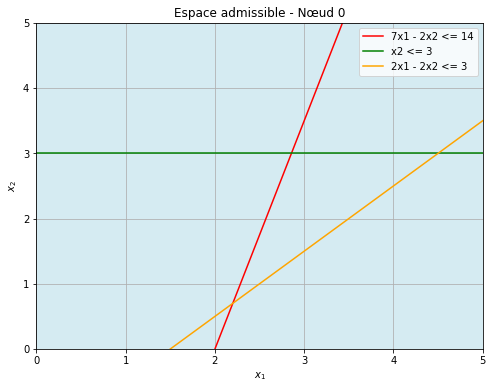

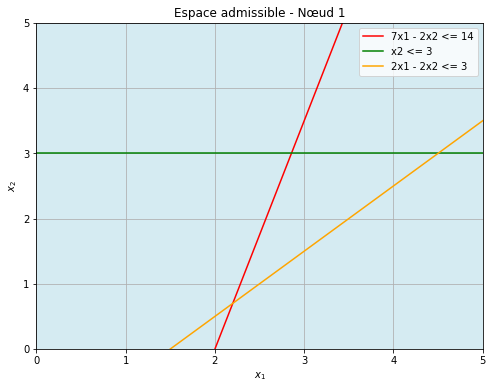

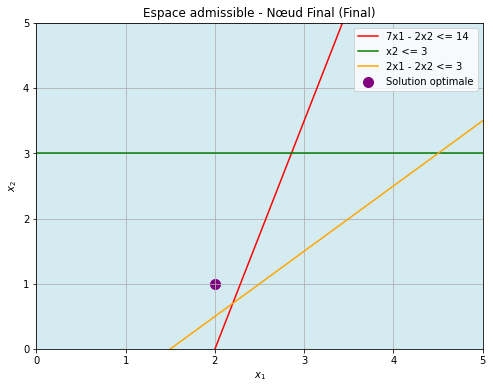

Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, '

In [71]:









import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from docplex.mp.model import Model

def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        visualize_node(sub_mdl, node_bounds, len(tree_nodes), is_final=False)

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    def visualize_node(model, bounds, node_id, is_final=False):
        x1 = np.linspace(0, 5, 400)
        x2 = np.linspace(0, 5, 400)
        X1, X2 = np.meshgrid(x1, x2)

        constraint1 = 7 * X1 - 2 * X2 <= 14
        constraint2 = X2 <= 3
        constraint3 = 2 * X1 - 2 * X2 <= 3
        constraint4 = (X1 >= bounds.get("x1", (0, 4))[0]) & (X1 <= bounds.get("x1", (0, 4))[1])
        constraint5 = (X2 >= bounds.get("x2", (0, 4))[0]) & (X2 <= bounds.get("x2", (0, 4))[1])

        admissible = constraint1 & constraint2 & constraint3 & constraint4 & constraint5

        if is_final and best_solution:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')
            plt.scatter(best_solution["x1"], best_solution["x2"], color='purple', s=100, label="Solution optimale")

            plt.title(f"Espace admissible - Nœud {node_id}" + (" (Final)" if is_final else ""))
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            plt.grid()
            plt.show()
        else:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')

            plt.title(f"Espace admissible - Nœud {node_id}")
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            plt.grid()
            plt.show()

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    if best_solution:
        visualize_node(mdl, {"x1": (0, 4), "x2": (0, 4)}, node_id="Final", is_final=True)

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)































In [38]:
import matplotlib.pyplot as plt
from docplex.mp.model import Model
import pandas as pd
import numpy as np



In [39]:
# Fonction pour résoudre un PLNE avec Branch and Bound et Docplex
def branch_and_bound_with_visualization(initial_lower_bound=5):
    # Définition du modèle initial
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    # Variables pour suivre l'arbre de recherche
    best_solution = None
    best_value = initial_lower_bound  # Initialisation avec la borne inférieure donnée
    tree_nodes = []
    node_table = []
    branch_table = []
    visualizations = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        # Créer un sous-modèle avec des bornes spécifiques
        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        # Résoudre la relaxation continue
        solution = sub_mdl.solve()
        if not solution:
            # Région non admissible
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        # Enregistrer la borne supérieure
        upper_bound = objective_value

        # Ajouter les informations du nœud au tableau
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        # Visualiser l'espace admissible
        visualizations.append((node_bounds, len(tree_nodes), sub_mdl))

        # Si la borne supérieure est inférieure à la meilleure valeur entière, couper la branche
        if upper_bound <= best_value:
            return

        # Vérifier si la solution est entière
        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            # Mettre à jour la borne inférieure si meilleure solution entière
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            # Brancher sur une variable non entière selon l'ordre donné
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        # Créer deux nouveaux nœuds
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        # Ajouter les informations de branchement
                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        # Explorer récursivement
                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        # Ajouter le nœud à la liste pour l'arbre
        tree_nodes.append((node_bounds, objective_value))

    # Initialisation
    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table), visualizations

# Résolution avec Branch and Bound
solution, optimal_value, tree_nodes, node_df, branch_df, visualizations = branch_and_bound_with_visualization(initial_lower_bound=5)

# Afficher la solution
print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)

# Afficher le tableau des nœuds
print("\nTableau des nœuds explorés :")
print(node_df)

# Afficher le tableau des branches
print("\nTableau des branches :")
print(branch_df)



Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, '

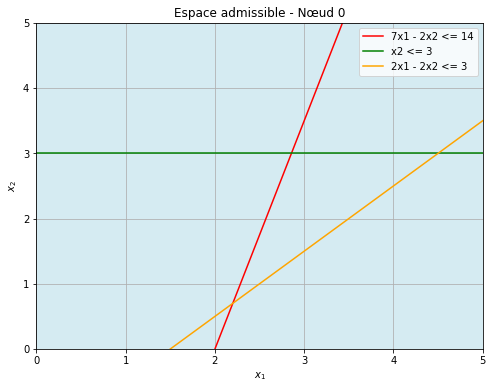

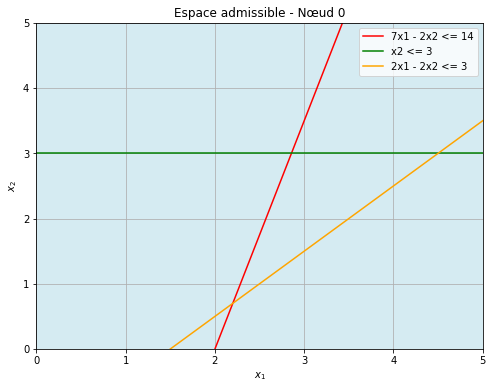

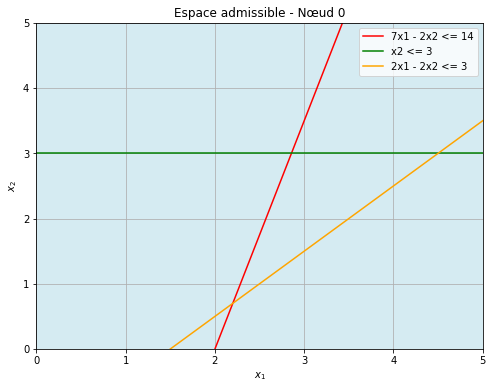

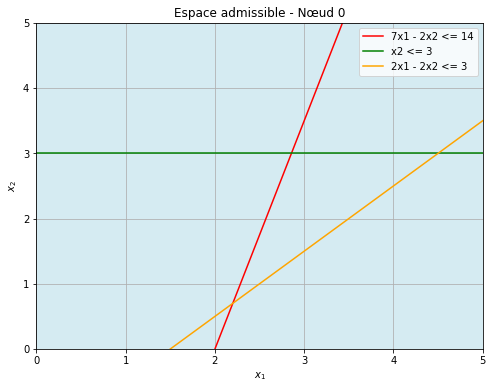

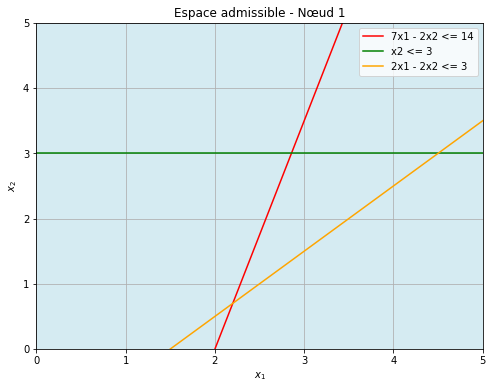

Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, '

In [55]:
import matplotlib.pyplot as plt
from docplex.mp.model import Model
import pandas as pd
import numpy as np

def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []
    visualizations = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        visualize_node(sub_mdl, node_bounds, len(tree_nodes))

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    def visualize_node(model, bounds, node_id):
        x1 = np.linspace(0, 5, 400)
        x2 = np.linspace(0, 5, 400)
        X1, X2 = np.meshgrid(x1, x2)

        constraint1 = 7 * X1 - 2 * X2 <= 14
        constraint2 = X2 <= 3
        constraint3 = 2 * X1 - 2 * X2 <= 3
        constraint4 = (X1 >= bounds.get("x1", (0, 4))[0]) & (X1 <= bounds.get("x1", (0, 4))[1])
        constraint5 = (X2 >= bounds.get("x2", (0, 4))[0]) & (X2 <= bounds.get("x2", (0, 4))[1])

        admissible = constraint1 & constraint2 & constraint3 & constraint4 & constraint5

        plt.figure(figsize=(8, 6))
        plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)

        plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
        plt.axhline(3, label="x2 <= 3", color='green')
        plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')

        plt.title(f"Espace admissible - Nœud {node_id}")
        plt.xlabel("$x_1$")
        plt.ylabel("$x_2$")
        plt.xlim(0, 5)
        plt.ylim(0, 5)
        plt.legend()
        plt.grid()
        plt.show()

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)

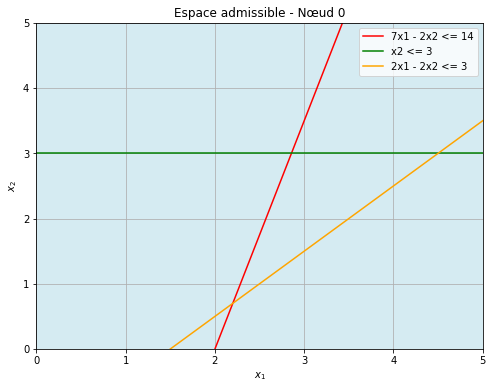

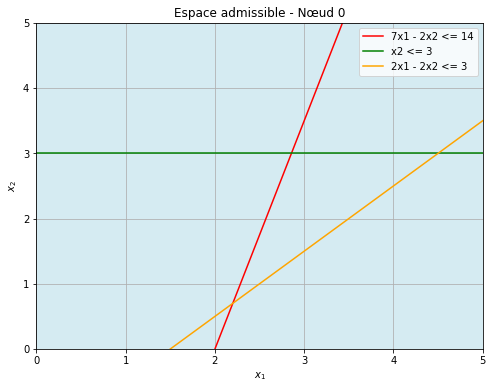

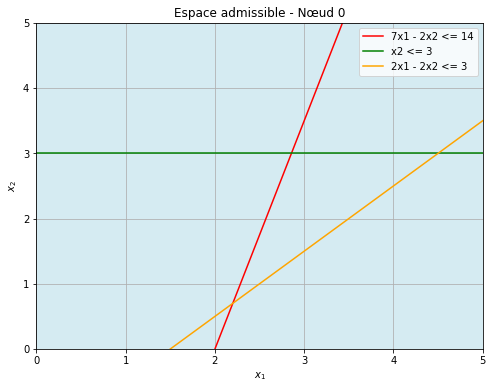

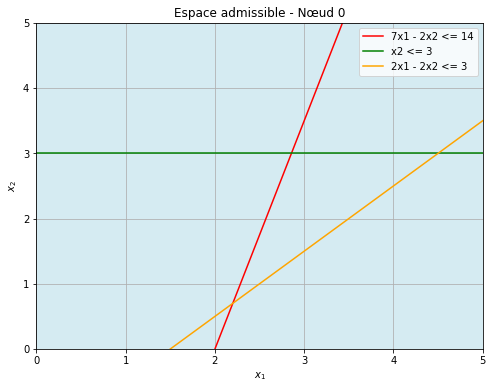

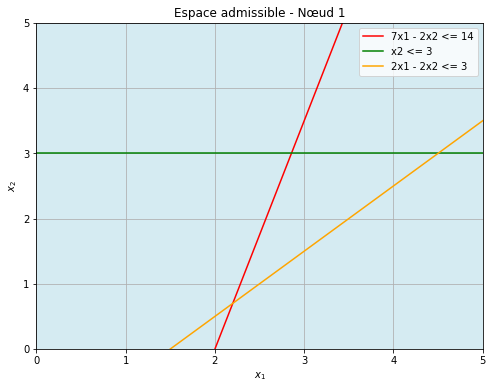

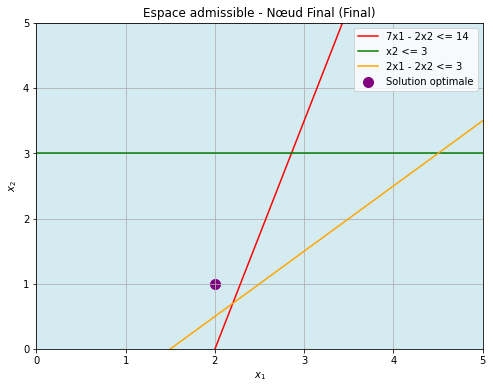

Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, '

In [56]:
import matplotlib.pyplot as plt
from docplex.mp.model import Model
import pandas as pd
import numpy as np

def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []
    visualizations = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        visualize_node(sub_mdl, node_bounds, len(tree_nodes), is_final=False)

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    def visualize_node(model, bounds, node_id, is_final=False):
        x1 = np.linspace(0, 5, 400)
        x2 = np.linspace(0, 5, 400)
        X1, X2 = np.meshgrid(x1, x2)

        constraint1 = 7 * X1 - 2 * X2 <= 14
        constraint2 = X2 <= 3
        constraint3 = 2 * X1 - 2 * X2 <= 3
        constraint4 = (X1 >= bounds.get("x1", (0, 4))[0]) & (X1 <= bounds.get("x1", (0, 4))[1])
        constraint5 = (X2 >= bounds.get("x2", (0, 4))[0]) & (X2 <= bounds.get("x2", (0, 4))[1])

        admissible = constraint1 & constraint2 & constraint3 & constraint4 & constraint5

        plt.figure(figsize=(8, 6))
        plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)

        plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
        plt.axhline(3, label="x2 <= 3", color='green')
        plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')

        if is_final and best_solution:
            plt.scatter(best_solution["x1"], best_solution["x2"], color='purple', s=100, label="Solution optimale")

        plt.title(f"Espace admissible - Nœud {node_id}" + (" (Final)" if is_final else ""))
        plt.xlabel("$x_1$")
        plt.ylabel("$x_2$")
        plt.xlim(0, 5)
        plt.ylim(0, 5)
        plt.legend()
        plt.grid()
        plt.show()

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    if best_solution:
        visualize_node(mdl, {"x1": (0, 4), "x2": (0, 4)}, node_id="Final", is_final=True)

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)

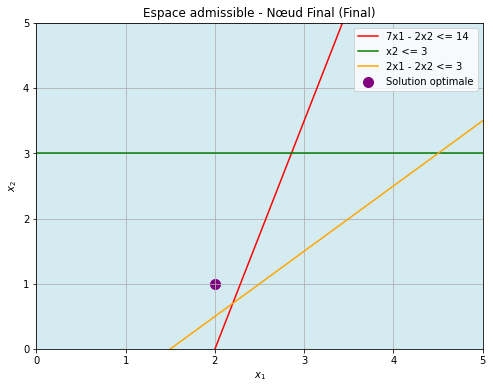

Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds     Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}        8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}             7.5   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}             6.0   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}             4.0   
4          0.0             0  {'x1': (2, 2), 'x2': (0, 0)}  Non admissible   
5          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}             7.0   
6          3.0             3  {'x1': (3, 4), 'x2': (0, 4)}  Non admissible   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, '

In [ ]:
# Visualiser les espaces admissibles pour chaque nœud
def plot_feasible_regions(visualizations):
    x1_range = np.linspace(0, 4, 400)
    plt.figure(figsize=(12, 12))
    plt.suptitle("Espace admissible pour chaque nœud exploré")

    for i, (bounds, node_id, sub_mdl) in enumerate(visualizations):
        plt.subplot(len(visualizations), 1, i + 1)
        plt.title(f"Nœud {node_id}: {bounds}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.xlim(0, 4)
        plt.ylim(0, 4)

        # Tracer les contraintes du polyèdre pour le nœud
        x2_1 = (14 - 7 * x1_range) / 2
        x2_2 = np.full_like(x1_range, 3)
        x2_3 = (3 - 2 * x1_range) / -2

        plt.fill_between(
            x1_range, 
            np.maximum(0, np.minimum.reduce([x2_1, x2_2, x2_3])),
            where=(x1_range >= bounds["x1"][0]) & (x1_range <= bounds["x1"][1]),
            color="lightblue", alpha=0.3
        )

        # Tracer les bornes spécifiques
        plt.axhline(bounds["x2"][1], color="red", linestyle="--", label="Upper Bound x2")
        plt.axhline(bounds["x2"][0], color="green", linestyle="--", label="Lower Bound x2")

        # Afficher les contraintes de l'espace admissible pour le nœud
        for constraint in sub_mdl.iter_constraints():
            coeffs = constraint.linear_coef
            rhs = constraint.rhs
            if "x1" in coeffs and "x2" in coeffs:
                a1 = coeffs["x1"]
                a2 = coeffs["x2"]
                if a2 != 0:
                    plt.plot(x1_range, (rhs - a1 * x1_range) / a2, label=f"{constraint}")

        plt.legend()
    plt.tight_layout()
    plt.show()

# Afficher les espaces admissibles
plot_feasible_regions(visualizations)


In [28]:
# Fonction pour résoudre un PLNE avec Branch and Bound et Docplex
def branch_and_bound_with_visualization(initial_lower_bound=5):
    # Définition du modèle initial
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    # Variables pour suivre l'arbre de recherche
    best_solution = None
    best_value = initial_lower_bound  # Initialisation avec la borne inférieure donnée
    tree_nodes = []
    node_table = []
    branch_table = []
    visualizations = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        # Créer un sous-modèle avec des bornes spécifiques
        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        # Résoudre la relaxation continue
        solution = sub_mdl.solve()
        if not solution:
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        # Enregistrer la borne supérieure
        upper_bound = objective_value

        # Ajouter les informations du nœud au tableau
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
            
        })

        # Visualiser l'espace admissible
        visualizations.append((node_bounds, len(tree_nodes), sub_mdl))

        # Si la borne supérieure est inférieure à la meilleure valeur entière, couper la branche
        if upper_bound <= best_value:
            return

        # Vérifier si la solution est entière
        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            # Mettre à jour la borne inférieure si meilleure solution entière
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            # Brancher sur une variable non entière selon l'ordre donné
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        # Créer deux nouveaux nœuds
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        # Ajouter les informations de branchement
                        node_table[-1]["Variable Branchée"] = var_name

                        # Ajouter au tableau des branches
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        # Explorer récursivement
                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        # Ajouter le nœud à la liste pour l'arbre
        tree_nodes.append((node_bounds, objective_value))

    # Initialisation
    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table), visualizations

# Résolution avec Branch and Bound
solution, optimal_value, tree_nodes, node_df, branch_df, visualizations = branch_and_bound_with_visualization(initial_lower_bound=5)

# Afficher la solution
print("Solution optimale:", solution)
print("Valeur optimale:", optimal_value)

# Afficher le tableau des nœuds
print("\nTableau des nœuds explorés :")
print(node_df)

# Afficher le tableau des branches
print("\nTableau des branches :")
print(branch_df)



Solution optimale: {'x1': 2.0, 'x2': 1.0}
Valeur optimale: 7.0

Tableau des nœuds explorés :
   Parent Node  Current Node                        Bounds  Upper Bound  \
0          NaN             0  {'x1': (0, 4), 'x2': (0, 4)}     8.428571   
1          0.0             0  {'x1': (0, 2), 'x2': (0, 4)}     7.500000   
2          0.0             0  {'x1': (0, 2), 'x2': (0, 0)}     6.000000   
3          0.0             0  {'x1': (0, 1), 'x2': (0, 0)}     4.000000   
4          1.0             1  {'x1': (0, 2), 'x2': (1, 4)}     7.000000   

   Lower Bound Variable Branchée                              Solution  
0          5.0                x1  {'x1': 2.857142857142857, 'x2': 3.0}  
1          5.0                x2                {'x1': 2.0, 'x2': 0.5}  
2          5.0                x1                  {'x1': 1.5, 'x2': 0}  
3          5.0              None                  {'x1': 1.0, 'x2': 0}  
4          7.0              None                {'x1': 2.0, 'x2': 1.0}  

Tableau des branc

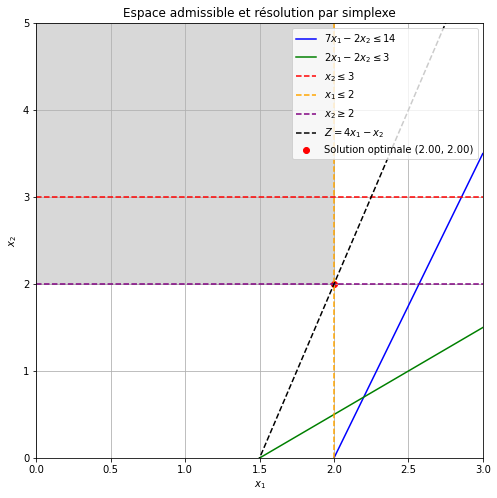

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Définir les coefficients de la fonction objectif
# Exemple : Max Z = 4x1 - x2
c = [-4, 1]  # On minimise en multipliant par -1 pour linprog

# Définir les coefficients des contraintes
# 7x1 - 2x2 <= 14
# x2 <= 3
# 2x1 - 2x2 <= 3
# x1 <= 2
# x2 >= 2

A = [
    [7, -2],  # 7x1 - 2x2
    [0, 1],   # x2
    [2, -2],  # 2x1 - 2x2
    [1, 0],   # x1
    [0, -1]   # -x2 (pour x2 >= 2)
]
b = [14, 3, 3, 2, -2]

# Résolution avec la méthode du simplexe
result = linprog(c, A_ub=A, b_ub=b, method="highs")

# Récupérer les points de la région faisable
x1 = np.linspace(0, 3, 400)

# Contraintes
x2_1 = (7 * x1 - 14) / 2  # 7x1 - 2x2 <= 14
x2_2 = 3  # x2 <= 3
x2_3 = x1 - 3 / 2  # 2x1 - 2x2 <= 3
x1_limit = 2  # x1 <= 2
x2_min = 2  # x2 >= 2

# Initialisation du graphique
plt.figure(figsize=(8, 8))

# Tracer les contraintes
plt.plot(x1, x2_1, label=r'$7x_1 - 2x_2 \leq 14$', color='blue')
plt.plot(x1, x2_3, label=r'$2x_1 - 2x_2 \leq 3$', color='green')
plt.axhline(y=x2_2, color='red', linestyle='--', label=r'$x_2 \leq 3$')
plt.axvline(x=x1_limit, color='orange', linestyle='--', label=r'$x_1 \leq 2$')
plt.axhline(y=x2_min, color='purple', linestyle='--', label=r'$x_2 \geq 2$')

# Déterminer la région faisable
x2_combined = np.maximum(np.maximum(2, (7 * x1 - 14) / 2), x1 - 3 / 2)  # Intersection des contraintes inférieures
x2_upper = np.minimum(3, x2_combined)  # Intersection avec les contraintes supérieures

# Remplir la région faisable
plt.fill_between(x1, x2_upper, 5, where=(x1 <= 2), color='gray', alpha=0.3)

# Tracer la fonction objectif
if result.success:
    Z = -result.fun  # Valeur optimale (on rechange le signe)
    x_opt = result.x
    x2_obj = (4 * x1 - Z)  # Droite de la fonction objectif
    plt.plot(x1, x2_obj, label=f'$Z = 4x_1 - x_2$', color='black', linestyle='--')
    plt.scatter(x_opt[0], x_opt[1], color='red', label=f'Solution optimale ({x_opt[0]:.2f}, {x_opt[1]:.2f})')
else:
    print("Aucune solution optimale trouvée.")

# Ajouter des étiquettes et une légende
plt.xlim(0, 3)
plt.ylim(0, 5)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Espace admissible et résolution par simplexe')
plt.legend(loc='upper right')
plt.grid(True)

# Afficher le graphique
plt.show()

Solution optimale : x1 = 2.00, x2 = 2.00, Z = 6.00


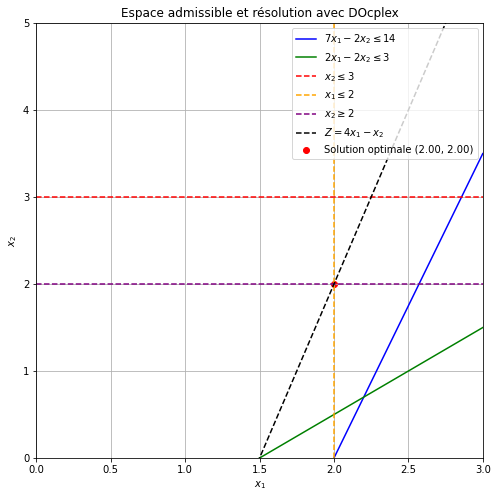

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle avec DOcplex
mdl = Model(name="Maximisation")

# Définition des variables
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Définition de la fonction objectif : Max Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Ajout des contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "c1")
mdl.add_constraint(x2 <= 3, "c2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "c3")
mdl.add_constraint(x1 <= 2, "c4")
mdl.add_constraint(x2 >= 2, "c5")

# Résolution du problème
solution = mdl.solve()

# Résultats
if solution:
    x1_opt = solution.get_value("x1")
    x2_opt = solution.get_value("x2")
    z_opt = solution.objective_value
    print(f"Solution optimale : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}, Z = {z_opt:.2f}")
else:
    print("Pas de solution optimale trouvée.")

# Visualisation de l'espace admissible
x1_vals = np.linspace(0, 3, 400)

# Définir les contraintes
x2_c1 = (7 * x1_vals - 14) / 2  # c1: 7x1 - 2x2 <= 14
x2_c3 = x1_vals - 3 / 2  # c3: 2x1 - 2x2 <= 3
x2_upper = np.minimum(3, np.minimum(x2_c1, x2_c3))  # Intersection des contraintes supérieures
x2_lower = np.maximum(2, 0)  # Contraintes inférieures (x2 >= 2)

# Initialisation de la figure
plt.figure(figsize=(8, 8))

# Tracer les contraintes
plt.plot(x1_vals, x2_c1, label=r'$7x_1 - 2x_2 \leq 14$', color='blue')
plt.plot(x1_vals, x2_c3, label=r'$2x_1 - 2x_2 \leq 3$', color='green')
plt.axhline(y=3, color='red', linestyle='--', label=r'$x_2 \leq 3$')
plt.axvline(x=2, color='orange', linestyle='--', label=r'$x_1 \leq 2$')
plt.axhline(y=2, color='purple', linestyle='--', label=r'$x_2 \geq 2$')

# Remplir la région faisable
plt.fill_between(x1_vals, x2_lower, x2_upper, where=(x2_lower <= x2_upper), color='gray', alpha=0.3)

# Tracer la fonction objectif
if solution:
    Z = z_opt
    x2_obj = 4 * x1_vals - Z  # Droite de la fonction objectif
    plt.plot(x1_vals, x2_obj, label=f'$Z = 4x_1 - x_2$', color='black', linestyle='--')
    plt.scatter(x1_opt, x2_opt, color='red', label=f'Solution optimale ({x1_opt:.2f}, {x2_opt:.2f})')

# Ajouter des étiquettes et une légende
plt.xlim(0, 3)
plt.ylim(0, 5)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Espace admissible et résolution avec DOcplex')
plt.legend(loc='upper right')
plt.grid(True)

# Afficher le graphique
plt.show()

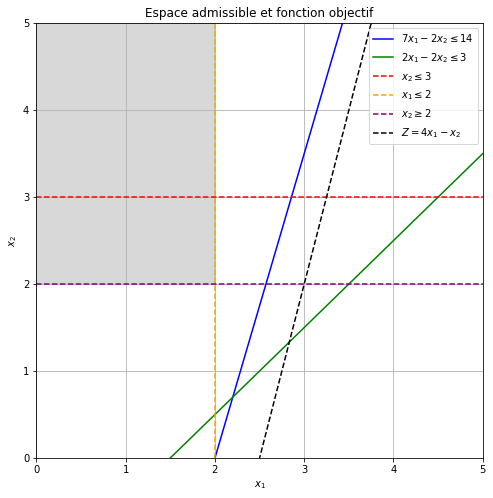

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Définir les limites pour les variables
x1 = np.linspace(0, 5, 400)  # Ajustez la plage selon vos besoins

# Définir les contraintes
x2_1 = (7*x1 - 14) / 2  # 7x1 - 2x2 <= 14
x2_2 = 3  # x2 <= 3
x2_3 = x1 - 3/2  # 2x1 - 2x2 <= 3
x1_limit = 2  # x1 <= 2
x2_min = 2  # x2 >= 2

# Initialisation de la figure
plt.figure(figsize=(8, 8))

# Tracer chaque contrainte
plt.plot(x1, x2_1, label=r'$7x_1 - 2x_2 \leq 14$', color='blue')
plt.plot(x1, x2_3, label=r'$2x_1 - 2x_2 \leq 3$', color='green')
plt.axhline(y=x2_2, color='red', linestyle='--', label=r'$x_2 \leq 3$')
plt.axvline(x=x1_limit, color='orange', linestyle='--', label=r'$x_1 \leq 2$')
plt.axhline(y=x2_min, color='purple', linestyle='--', label=r'$x_2 \geq 2$')

# Déterminer la région faisable
x2_combined = np.maximum(np.maximum(2, (7*x1 - 14) / 2), x1 - 3/2)  # Intersection des contraintes inférieures
x2_upper = np.minimum(3, x2_combined)  # Intersection avec les contraintes supérieures

# Remplir la région faisable
plt.fill_between(x1, x2_upper, 5, where=(x1 <= 2), color='gray', alpha=0.3)

# Tracer la fonction objectif (exemple: Z = 4x1 - x2)
Z = 10  # Exemple de valeur pour Z
x2_obj = 4*x1 - Z
plt.plot(x1, x2_obj, label=r'$Z = 4x_1 - x_2$', color='black', linestyle='--')

# Ajouter des labels, une légende, et des limites
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Espace admissible et fonction objectif')
plt.legend(loc='upper right')
plt.grid(True)

# Afficher le graphique
plt.show()

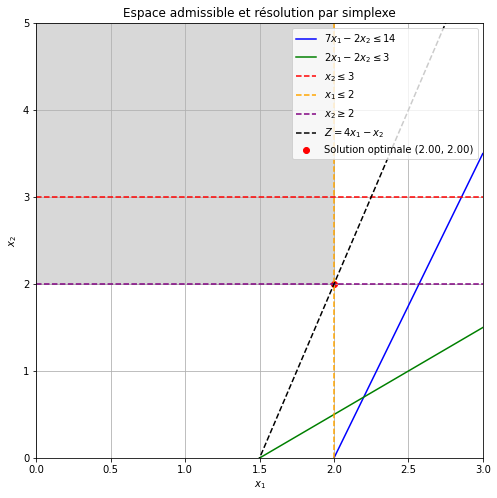

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Définir les coefficients de la fonction objectif
# Exemple : Max Z = 4x1 - x2
c = [-4, 1]  # On minimise en multipliant par -1 pour linprog

# Définir les coefficients des contraintes
# 7x1 - 2x2 <= 14
# x2 <= 3
# 2x1 - 2x2 <= 3
# x1 <= 2
# x2 >= 2

A = [
    [7, -2],  # 7x1 - 2x2
    [0, 1],   # x2
    [2, -2],  # 2x1 - 2x2
    [1, 0],   # x1
    [0, -1]   # -x2 (pour x2 >= 2)
]
b = [14, 3, 3, 2, -2]

# Résolution avec la méthode du simplexe
result = linprog(c, A_ub=A, b_ub=b, method="highs")

# Récupérer les points de la région faisable
x1 = np.linspace(0, 3, 400)

# Contraintes
x2_1 = (7 * x1 - 14) / 2  # 7x1 - 2x2 <= 14
x2_2 = 3  # x2 <= 3
x2_3 = x1 - 3 / 2  # 2x1 - 2x2 <= 3
x1_limit = 2  # x1 <= 1
x2_min = 2  # x2 >= 2

# Initialisation du graphique
plt.figure(figsize=(8, 8))

# Tracer les contraintes
plt.plot(x1, x2_1, label=r'$7x_1 - 2x_2 \leq 14$', color='blue')
plt.plot(x1, x2_3, label=r'$2x_1 - 2x_2 \leq 3$', color='green')
plt.axhline(y=x2_2, color='red', linestyle='--', label=r'$x_2 \leq 3$')
plt.axvline(x=x1_limit, color='orange', linestyle='--', label=r'$x_1 \leq 2$')
plt.axhline(y=x2_min, color='purple', linestyle='--', label=r'$x_2 \geq 2$')

# Déterminer la région faisable
x2_combined = np.maximum(np.maximum(2, (7 * x1 - 14) / 2), x1 - 3 / 2)  # Intersection des contraintes inférieures
x2_upper = np.minimum(3, x2_combined)  # Intersection avec les contraintes supérieures

# Remplir la région faisable
plt.fill_between(x1, x2_upper, 5, where=(x1 <= 2), color='gray', alpha=0.3)

# Tracer la fonction objectif
if result.success:
    Z = -result.fun  # Valeur optimale (on rechange le signe)
    x_opt = result.x
    x2_obj = (4 * x1 - Z)  # Droite de la fonction objectif
    plt.plot(x1, x2_obj, label=f'$Z = 4x_1 - x_2$', color='black', linestyle='--')
    plt.scatter(x_opt[0], x_opt[1], color='red', label=f'Solution optimale ({x_opt[0]:.2f}, {x_opt[1]:.2f})')
else:
    print("Aucune solution optimale trouvée.")

# Ajouter des étiquettes et une légende
plt.xlim(0, 3)
plt.ylim(0, 5)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Espace admissible et résolution par simplexe')
plt.legend(loc='upper right')
plt.grid(True)

# Afficher le graphique
plt.show()

In [52]:
         # Visualiser les espaces admissibles pour chaque nœud
def plot_feasible_regions(visualizations):
    x1_range = np.linspace(0, 4, 400)
    plt.figure(figsize=(12, 12))
    plt.suptitle("Espace admissible pour chaque nœud exploré")

    for i, (bounds, node_id, sub_mdl) in enumerate(visualizations):
        plt.subplot(len(visualizations), 1, i + 1)
        plt.title(f"Nœud {node_id}: {bounds}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.xlim(0, 4)
        plt.ylim(0, 4)

        # Tracer les contraintes du polyèdre pour le nœud
        x2_1 = (14 - 7 * x1_range) / 2
        x2_2 = np.full_like(x1_range, 3)
        x2_3 = (3 - 2 * x1_range) / -2

        plt.fill_between(
            x1_range, 
            np.maximum(0, np.minimum.reduce([x2_1, x2_2, x2_3])),
            where=(x1_range >= bounds["x1"][0]) & (x1_range <= bounds["x1"][1]),
            color="lightblue", alpha=0.3
        )

        # Tracer les bornes spécifiques
        plt.axhline(bounds["x2"][1], color="red", linestyle="--", label="Upper Bound x2")
        plt.axhline(bounds["x2"][0], color="green", linestyle="--", label="Lower Bound x2")

        # Afficher les contraintes de l'espace admissible pour le nœud
        for constraint in sub_mdl.iter_constraints():
            coeffs = constraint.linear_coef
            rhs = constraint.rhs
            if "x1" in coeffs and "x2" in coeffs:
                a1 = coeffs["x1"]
                a2 = coeffs["x2"]
                if a2 != 0:
                    plt.plot(x1_range, (rhs - a1 * x1_range) / a2, label=f"{constraint}")

        plt.legend()
    plt.tight_layout()
    plt.show()

# Afficher les espaces admissibles
plot_feasible_regions(visualizations)
       

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 33)

In [54]:
from docplex.mp.model import Model

# Création du modèle
model = Model(name="Maximize_4x1_minus_x2_with_integers")

# Variables de décision (entières)
x1 = model.integer_var(name="x1")  # x1 est une variable entière
x2 = model.integer_var(name="x2")  # x2 est aussi une variable entière

# Fonction objectif
model.maximize(4 * x1 - x2)

# Contraintes
model.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
model.add_constraint(x2 <= 3, "Constraint2")
model.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
model.add_constraint(x1 <= 2, "Constraint4")
model.add_constraint(x2 >= 2, "Constraint5")

# Résolution
solution = model.solve()

# Affichage des résultats
if solution:
    print(f"Solution trouvée :")
    print(f"x1 = {solution[x1]:.0f}")  # x1 est entier
    print(f"x2 = {solution[x2]:.0f}")  # x2 est entier
    print(f"Valeur optimale de z = {solution.objective_value:.2f}")
else:
    print("Aucune solution réalisable trouvée.")

Solution trouvée :
x1 = 2
x2 = 2
Valeur optimale de z = 6.00


Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 6 rows and 2 columns.
All rows and columns eliminated.
Presolve time = 0.02 sec. (0.00 ticks)
Point optimal : x1 = 2.00, x2 = 1.00
Valeur optimale de Z : 7.00


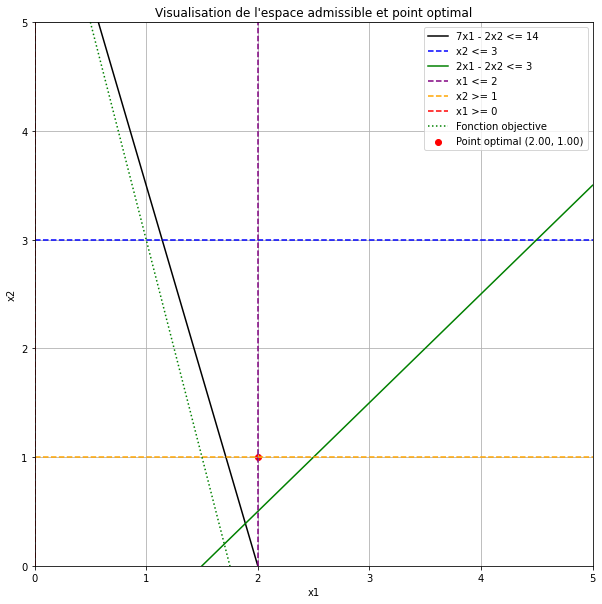

In [162]:
from docplex.mp.model import Model
import numpy as np
import matplotlib.pyplot as plt

# Création du modèle
mdl = Model(name="PL_2_Variables")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective : Maximiser Z = 4x1 - x2
mdl.maximize(4 * x1 - x2)

# Contraintes
mdl.add_constraint(7 * x1 - 2 * x2 <= 14, "Constraint1")
mdl.add_constraint(x2 <= 3, "Constraint2")
mdl.add_constraint(2 * x1 - 2 * x2 <= 3, "Constraint3")
mdl.add_constraint(x1 <= 2, "Constraint4")
mdl.add_constraint(x2 >= 1, "Constraint5")
mdl.add_constraint(x1 >= 0, "Constraint6")

# Résolution
solution = mdl.solve(log_output=True)

# Vérification de la solution
if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z : {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 5, 500)  # Étendue pour x1
y = np.linspace(0, 5, 500)  # Étendue pour x2
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y >= 1)
c6 = (X >= 0)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5 & c6

# Tracer la région faisable
plt.figure(figsize=(10, 10))
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['white', 'yellow'], alpha=0.7)

# Tracer les lignes des contraintes
plt.plot(x, (14 - 7 * x) / 2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")
plt.axvline(0, color="red", linestyle="--", label="x1 >= 0")

# Tracer le point optimal
plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer la fonction objective
z_line = z_opt - 4 * x  # Représentation de la fonction objective
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")

# Configuration du graphique
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Visualisation de l'espace admissible et point optimal")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
No LP presolve or aggregator reductions.
Presolve time = 0.13 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual infeasibility =             0.000000
Iteration:     2   Dual objective     =            16.666667
Point optimal (relaxation) : x1 = 3.33, x2 = 1.33
Valeur optimale de Z (relaxation) : 16.67


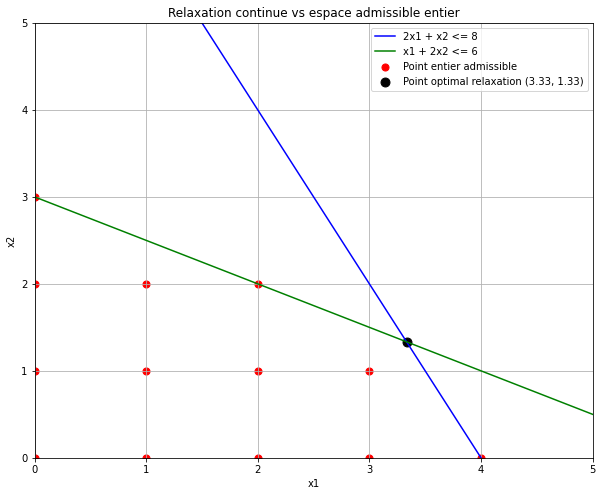

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name="Relaxation_Continue")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective
mdl.maximize(3 * x1 + 5 * x2)

# Contraintes
mdl.add_constraint(2 * x1 + x2 <= 8, "Constraint1")
mdl.add_constraint(x1 + 2 * x2 <= 6, "Constraint2")

# Résolution
solution = mdl.solve(log_output=True)

# Vérification de la solution
if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal (relaxation) : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z (relaxation) : {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 10, 500)
y = np.linspace(0, 10, 500)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
constraint1 = (2 * X + Y <= 8)
constraint2 = (X + 2 * Y <= 6)
feasible_region = constraint1 & constraint2

# Tracer la région faisable
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['white', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (8 - 2 * x), label="2x1 + x2 <= 8", color="blue")
plt.plot(x, (6 - x) / 2, label="x1 + 2x2 <= 6", color="green")

# Points entiers admissibles
x1_vals = np.arange(0, 10)
x2_vals = np.arange(0, 10)
for x1_i in x1_vals:
    for x2_i in x2_vals:
        if 2 * x1_i + x2_i <= 8 and x1_i + 2 * x2_i <= 6:
            plt.scatter(x1_i, x2_i, color="red", s=50, label="Point entier admissible" if x1_i == 0 and x2_i == 0 else "")

# Tracer le point optimal (relaxation)
if solution:
    plt.scatter(x1_opt, x2_opt, color="black", s=80, label=f"Point optimal relaxation ({x1_opt:.2f}, {x2_opt:.2f})")

# Configuration du graphique
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Relaxation continue vs espace admissible entier")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
No LP presolve or aggregator reductions.
Presolve time = 0.00 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual infeasibility =             0.000000
Iteration:     2   Dual objective     =            16.666667
Point optimal (relaxation) : x1 = 3.33, x2 = 1.33
Valeur optimale de Z (relaxation) : 16.67


<ipython-input-165-3a9b90b7f8da>:46: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['yellow'], alpha=0.5, label="Relaxation continue")


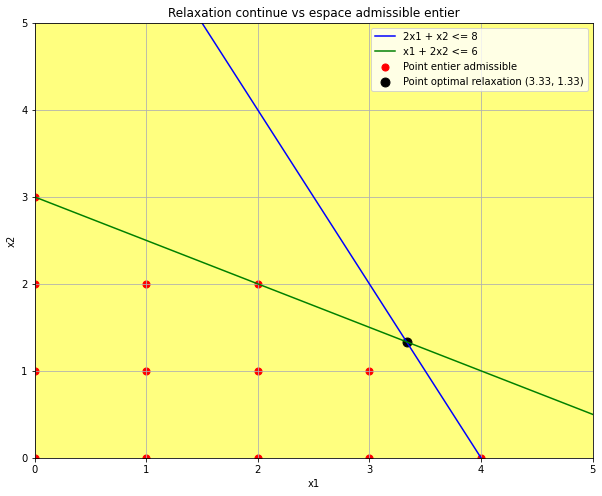

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name="Relaxation_vs_Entier")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective
mdl.maximize(3 * x1 + 5 * x2)

# Contraintes
mdl.add_constraint(2 * x1 + x2 <= 8, "Constraint1")
mdl.add_constraint(x1 + 2 * x2 <= 6, "Constraint2")

# Résolution
solution = mdl.solve(log_output=True)

# Vérification de la solution
if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal (relaxation) : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z (relaxation) : {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 10, 500)
y = np.linspace(0, 10, 500)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
constraint1 = (2 * X + Y <= 8)
constraint2 = (X + 2 * Y <= 6)
feasible_region = constraint1 & constraint2

# Tracer les contraintes
plt.figure(figsize=(10, 8))

# Espace admissible de la relaxation continue (en jaune)
plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['yellow'], alpha=0.5, label="Relaxation continue")

# Points admissibles pour le problème entier
x1_vals = np.arange(0, 10)
x2_vals = np.arange(0, 10)
for x1_i in x1_vals:
    for x2_i in x2_vals:
        if 2 * x1_i + x2_i <= 8 and x1_i + 2 * x2_i <= 6:
            plt.scatter(x1_i, x2_i, color="red", s=50, label="Point entier admissible" if x1_i == 0 and x2_i == 0 else "")

# Tracer le point optimal (relaxation)
if solution:
    plt.scatter(x1_opt, x2_opt, color="black", s=80, label=f"Point optimal relaxation ({x1_opt:.2f}, {x2_opt:.2f})")

# Tracer les lignes des contraintes
plt.plot(x, (8 - 2 * x), label="2x1 + x2 <= 8", color="blue")
plt.plot(x, (6 - x) / 2, label="x1 + 2x2 <= 6", color="green")

# Configuration du graphique
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Relaxation continue vs espace admissible entier")
plt.legend()
plt.grid()
plt.show()

Version identifier: 22.1.0.0 | 2022-03-25 | 54982fbec
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
No LP presolve or aggregator reductions.
Presolve time = 0.02 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual infeasibility =             0.000000
Iteration:     2   Dual objective     =            16.666667
Point optimal (relaxation) : x1 = 3.33, x2 = 1.33
Valeur optimale de Z (relaxation) : 16.67


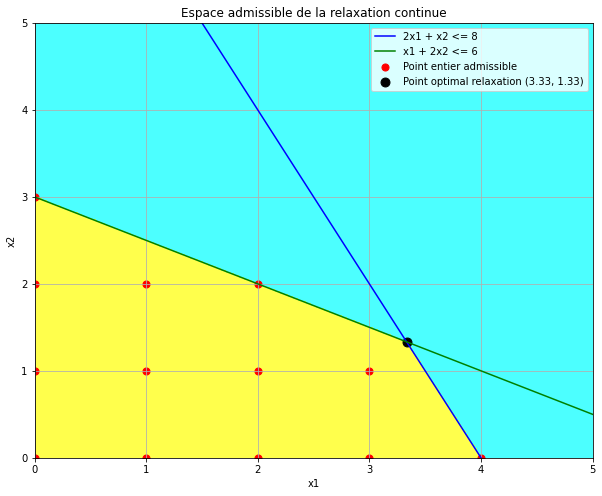

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model

# Création du modèle
mdl = Model(name="Relaxation_vs_Entier")

# Variables de décision
x1 = mdl.continuous_var(name="x1", lb=0)
x2 = mdl.continuous_var(name="x2", lb=0)

# Fonction objective
mdl.maximize(3 * x1 + 5 * x2)

# Contraintes
mdl.add_constraint(2 * x1 + x2 <= 8, "Constraint1")
mdl.add_constraint(x1 + 2 * x2 <= 6, "Constraint2")

# Résolution
solution = mdl.solve(log_output=True)

if solution:
    x1_opt = solution.get_value(x1)
    x2_opt = solution.get_value(x2)
    z_opt = solution.objective_value
    print(f"Point optimal (relaxation) : x1 = {x1_opt:.2f}, x2 = {x2_opt:.2f}")
    print(f"Valeur optimale de Z (relaxation) : {z_opt:.2f}")
else:
    print("Aucune solution trouvée.")

# Visualisation graphique
x = np.linspace(0, 10, 500)
y = np.linspace(0, 10, 500)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
constraint1 = (2 * X + Y <= 8)
constraint2 = (X + 2 * Y <= 6)
feasible_region = constraint1 & constraint2

# Tracer les contraintes et l'espace faisable
plt.figure(figsize=(10, 8))

# Espace faisable uniquement (intersection des contraintes en jaune)
#plt.contourf(X, Y, feasible_region, levels=[0, 1], colors=['yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (8 - 2 * x), label="2x1 + x2 <= 8", color="blue")
plt.plot(x, (6 - x) / 2, label="x1 + 2x2 <= 6", color="green")

# Points admissibles pour le problème entier
x1_vals = np.arange(0, 10)
x2_vals = np.arange(0, 10)
for x1_i in x1_vals:
    for x2_i in x2_vals:
        if 2 * x1_i + x2_i <= 8 and x1_i + 2 * x2_i <= 6:
            plt.scatter(x1_i, x2_i, color="red", s=50, label="Point entier admissible" if x1_i == 0 and x2_i == 0 else "")

# Tracer le point optimal
if solution:
    plt.scatter(x1_opt, x2_opt, color="black", s=80, label=f"Point optimal relaxation ({x1_opt:.2f}, {x2_opt:.2f})")

# Configuration du graphique
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espace admissible de la relaxation continue")
plt.legend()
plt.grid()
plt.show()

In [ ]:






















import matplotlib.pyplot as plt
from docplex.mp.model import Model
import numpy as np
  

    # Algorithme Branch end Bound pour résoudre un PLNE
    
def branch_and_bound_with_visualization(initial_lower_bound=5):
    mdl = Model(name="Branch and Bound PLNE")
    x1 = mdl.continuous_var(name="x1", lb=0, ub=4)
    x2 = mdl.continuous_var(name="x2", lb=0, ub=4)
    mdl.maximize(4 * x1 - x2)
    mdl.add_constraint(7 * x1 - 2 * x2 <= 14)
    mdl.add_constraint(x2 <= 3)
    mdl.add_constraint(2 * x1 - 2 * x2 <= 3)

    best_solution = None
    best_value = initial_lower_bound
    tree_nodes = []
    node_table = []
    branch_table = []

    def branch_and_solve(node_bounds, parent_node=None, branch_order=["x1", "x2"]):
        nonlocal best_solution, best_value

        sub_mdl = mdl.clone()
        for var_name, bounds in node_bounds.items():
            var = sub_mdl.get_var_by_name(var_name)
            sub_mdl.add_constraint(var >= bounds[0])
            sub_mdl.add_constraint(var <= bounds[1])

        solution = sub_mdl.solve()
        if not solution:
            node_table.append({
                "Parent Node": parent_node,
                "Current Node": len(tree_nodes),
                "Bounds": node_bounds,
                "Upper Bound": "Non admissible",
                "Lower Bound": best_value,
                "Variable Branchée": None,
                "Solution": None
            })
            return

        objective_value = sub_mdl.objective_value
        solution_values = {v.name: solution[v] for v in sub_mdl.iter_variables()}

        upper_bound = objective_value
        node_table.append({
            "Parent Node": parent_node,
            "Current Node": len(tree_nodes),
            "Bounds": node_bounds,
            "Upper Bound": upper_bound,
            "Lower Bound": best_value,
            "Variable Branchée": None,
            "Solution": solution_values
        })

        visualize_node(sub_mdl, node_bounds, len(tree_nodes), is_final=False)

        if upper_bound <= best_value:
            return

        if all(abs(solution_values[var_name] - round(solution_values[var_name])) < 1e-6 for var_name in node_bounds):
            if objective_value > best_value:
                best_solution = solution_values
                best_value = objective_value
                node_table[-1]["Lower Bound"] = best_value
        else:
            for var_name in branch_order:
                if var_name in solution_values:
                    value = solution_values[var_name]
                    if abs(value - round(value)) > 1e-6:
                        lower_bounds = node_bounds.copy()
                        upper_bounds = node_bounds.copy()
                        lower_bounds[var_name] = (node_bounds[var_name][0], int(np.floor(value)))
                        upper_bounds[var_name] = (int(np.ceil(value)), node_bounds[var_name][1])

                        node_table[-1]["Variable Branchée"] = var_name
                        branch_table.append({
                            "Node": len(tree_nodes),
                            "Variable": var_name,
                            "Value": value,
                            "Lower Branch Bounds": lower_bounds,
                            "Upper Branch Bounds": upper_bounds
                        })

                        branch_and_solve(lower_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        branch_and_solve(upper_bounds, parent_node=len(tree_nodes), branch_order=branch_order)
                        break

        tree_nodes.append((node_bounds, objective_value))

    def visualize_node(model, bounds, node_id, is_final=False):
        x1 = np.linspace(0, 5, 400)
        x2 = np.linspace(0, 5, 400)
        X1, X2 = np.meshgrid(x1, x2)

        constraint1 = 7 * X1 - 2 * X2 <= 14
        constraint2 = X2 <= 3
        constraint3 = 2 * X1 - 2 * X2 <= 3
        constraint4 = (X1 >= bounds.get("x1", (0, 4))[0]) & (X1 <= bounds.get("x1", (0, 4))[1])
        constraint5 = (X2 >= bounds.get("x2", (0, 4))[0]) & (X2 <= bounds.get("x2", (0, 4))[1])

        admissible = constraint1 & constraint2 & constraint3 & constraint4 & constraint5

        #plt.figure(figsize=(8, 6))
        #plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)

        #plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
        #plt.axhline(3, label="x2 <= 3", color='green')
        #plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')

        #if "x1" in bounds:
         #   plt.axvline(bounds["x1"][0], color='purple', linestyle="--", label=f"x1 >= {bounds['x1'][0]}")
          #  plt.axvline(bounds["x1"][1], color='purple', linestyle="--", label=f"x1 <= {bounds['x1'][1]}")
        #if "x2" in bounds:
         #   plt.axhline(bounds["x2"][0], color='blue', linestyle="--", label=f"x2 >= {bounds['x2'][0]}")
          #  plt.axhline(bounds["x2"][1], color='blue', linestyle="--", label=f"x2 <= {bounds['x2'][1]}")

        if is_final and best_solution:
            plt.figure(figsize=(8, 6))
            plt.contourf(X1, X2, admissible, levels=[0, 1], colors=['lightblue'], alpha=0.5)
            plt.plot(x1, (7 * x1 - 14) / 2, label="7x1 - 2x2 <= 14", color='red')
            plt.axhline(3, label="x2 <= 3", color='green')
            plt.plot(x1, (2 * x1 - 3) / 2, label="2x1 - 2x2 <= 3", color='orange')
            plt.scatter(best_solution["x1"], best_solution["x2"], color='purple', s=100, label="Solution optimale")
            # Visualisation de la droite de la fonction objective
            #x2_values = 4 * x1 - best_solution["x2"]  # Calcul des valeurs de x2 pour la droite de la fonction objectif
            #x2 = -0.5 * x1 + 1  
            #plt.plot(x1, x2, label="Droite de la fonction objective", color='blue', linestyle='dashed')
            #plt.plot(x1, x2_values, label="Droite de la fonction objective", color='blue', linestyle='dashed')

            plt.title(f"Espace admissible - Nœud {node_id}" + (" (Final)" if is_final else ""))
            plt.xlabel("$x_1$")
            plt.ylabel("$x_2$")
            plt.legend()
            plt.xlim(0, 5)
            plt.ylim(0, 5)
            #plt.legend()
            plt.grid()
            plt.show()

    initial_bounds = {"x1": (0, 4), "x2": (0, 4)}
    branch_and_solve(initial_bounds, branch_order=["x1", "x2", "x1"])

    if best_solution:
        visualize_node(mdl, {"x1": (0, 4), "x2": (0, 4)}, node_id="Final", is_final=True)

    return best_solution, best_value, tree_nodes, pd.DataFrame(node_table), pd.DataFrame(branch_table)

solution, optimal_value, tree_nodes, node_df, branch_df = branch_and_bound_with_visualization(initial_lower_bound=5)

# Affichage des résultats
print("\n--- Résultats de l'algorithme Branch and Bound ---")
print(f"La solution optimale de l'algorithme Branch and Bound est : {solution}")
print(f"La valeur optimale associée est : {optimal_value}")
print("\nTableau des nœuds explorés :")
print(node_df)
print("\nTableau des branches :")
print(branch_df)


# Visualisation graphique
x = np.linspace(0, 4, 400)
y = np.linspace(0, 4, 400)
X, Y = np.meshgrid(x, y)

# Contraintes sous forme de fonctions
c1 = (7 * X - 2 * Y <= 14)
c2 = (Y <= 3)
c3 = (2 * X - 2 * Y <= 3)
c4 = (X <= 2)
c5 = (Y >= 1)

# Région faisable
feasible_region = c1 & c2 & c3 & c4 & c5

# Tracer la région faisable
plt.figure(figsize=(10, 10))
#plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['blue', 'yellow'], alpha=0.7)
plt.contourf(X, Y, feasible_region, levels=[0, 0.5, 1], colors=['cyan', 'yellow'], alpha=0.7)

# Tracer les contraintes
plt.plot(x, (14 - 7 * x) / -2, label="7x1 - 2x2 <= 14", color="black")
plt.axhline(3, color="blue", linestyle="--", label="x2 <= 3")
plt.plot(x, x - 1.5, label="2x1 - 2x2 <= 3", color="green")
plt.axvline(2, color="purple", linestyle="--", label="x1 <= 2")
plt.axhline(1, color="orange", linestyle="--", label="x2 >= 1")

# Tracer le point optimal
#plt.scatter(x1_opt, x2_opt, color="red", label=f"Point optimal ({x1_opt:.2f}, {x2_opt:.2f})")
#solution
# Tracer la fonction objective
z_line = (4 * x - z_opt)
plt.plot(x, z_line, color="green", linestyle=":", label="Fonction objective")


# Configuration du graphique
plt.title("Espace admissible en jaune et reste en bleu")
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()




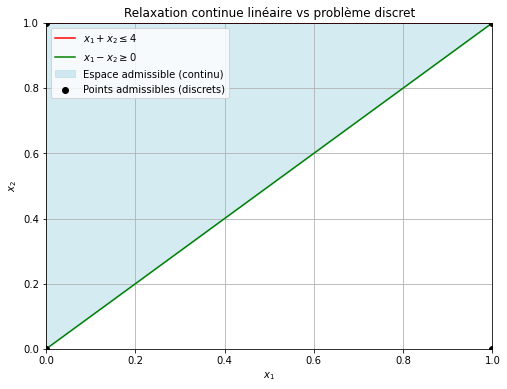

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Définir les contraintes
x1 = np.linspace(0, 1, 100)  # Domaine pour x1
x2_1 = 4 - x1  # Ligne pour x1 + x2 <= 4
x2_2 = x1      # Ligne pour x1 - x2 >= 0

# Limiter x2 dans [0, 1]
x2_1 = np.clip(x2_1, 0, 1)

# Points discrets
discrete_points = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])

# Tracé
plt.figure(figsize=(8, 6))

# Remplir l'espace admissible (polygone)
plt.fill_between(x1, x2_2, x2_1, where=(x2_1 >= x2_2), color='lightblue', alpha=0.5, label='Espace admissible (continu)')

# Tracer les contraintes
plt.plot(x1, x2_1, 'r-', label='$x_1 + x_2 \leq 4$')
plt.plot(x1, x2_2, 'g-', label='$x_1 - x_2 \geq 0$')

# Points discrets
plt.scatter(discrete_points[:, 0], discrete_points[:, 1], color='black', label='Points admissibles (discrets)', zorder=5)

# Axes et légendes
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Relaxation continue linéaire vs problème discret')
plt.legend()
plt.grid()
plt.show()